# Financial Fraud Detection System

## 01 — Dataset Exploration

This notebook performs exploratory data analysis on the
**CiferAI/Cifer-Fraud-Detection-Dataset-AF** dataset used by the
Financial Fraud Detection System.

### Objectives

- inspect the real source dataset
- verify the transaction schema
- measure fraud class imbalance
- analyze transaction-type behavior
- compare fraudulent and legitimate transaction amounts
- inspect sender and recipient balance changes
- examine the dataset's existing fraud-flag field
- identify patterns that may help the fine-tuned model
- establish evidence for the later data-preparation and fine-tuning stages

### Important

The source dataset is very large, so local exploratory analysis uses
Hugging Face streaming and a reproducible sample instead of downloading
the complete dataset to the local machine.

The production training pipeline remains separate and is implemented in
`ml/src/data/`.


## 1. Environment Setup

The notebook automatically locates the project root so it works when
opened from VS Code, Jupyter, or another notebook environment inside the
repository.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import Dataset, load_dataset

current_path = Path.cwd().resolve()

candidate_paths = [
    current_path,
    *current_path.parents,
]

PROJECT_ROOT = next(
    (
        path
        for path in candidate_paths
        if (path / "ml").is_dir()
        and (path / "evaluation").is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise RuntimeError(
        "Unable to locate the Financial Fraud Detection System project root."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ml.src.utils.constants import (
    DATASET_ID,
    DATASET_SPLIT,
    EXPECTED_TRANSACTION_TYPES,
    FRAUD_CLASS,
    FRAUD_LABEL_COLUMN,
    LEGITIMATE_CLASS,
    RANDOM_SEED,
    REQUIRED_COLUMNS,
)

from ml.src.utils.seed import set_global_seed

set_global_seed()

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATASET_ID)
print("Source split:", DATASET_SPLIT)
print("Random seed:", RANDOM_SEED)


Project root: /Users/ebbejulankapalli/Financial Fraud Detection System
Dataset: CiferAI/Cifer-Fraud-Detection-Dataset-AF
Source split: train
Random seed: 42


## 2. EDA Configuration

Training and fine-tuning use their own data pipeline.

For local exploratory analysis, this notebook uses a reproducible
**100,000-transaction streamed sample** so that the full multi-million-row
dataset does not need to be downloaded to the Mac.


In [2]:
EDA_SAMPLE_SIZE = 100_000
STREAM_SHUFFLE_BUFFER = 20_000

print(f"EDA sample size: {EDA_SAMPLE_SIZE:,}")
print(f"Streaming shuffle buffer: {STREAM_SHUFFLE_BUFFER:,}")


EDA sample size: 100,000
Streaming shuffle buffer: 20,000


## 3. Connect to the Real Cifer Dataset

Streaming allows records to be consumed progressively instead of first
materializing the complete source dataset locally.

A deterministic shuffle buffer reduces source-order bias before the EDA
sample is collected.


In [3]:
streamed_dataset = load_dataset(
    DATASET_ID,
    split=DATASET_SPLIT,
    streaming=True,
)

streamed_dataset = streamed_dataset.shuffle(
    seed=RANDOM_SEED,
    buffer_size=STREAM_SHUFFLE_BUFFER,
)

sample_records = list(
    streamed_dataset.take(EDA_SAMPLE_SIZE)
)

if not sample_records:
    raise RuntimeError(
        "No transactions were returned from the source dataset."
    )

eda_dataset = Dataset.from_list(sample_records)
df = eda_dataset.to_pandas()

print(f"Loaded EDA transactions: {len(df):,}")


Loaded EDA transactions: 100,000


## 4. Dataset Schema

The source dataset contains additional metadata fields, but the fraud
detector itself will later use only the transaction fields defined by the
project's ML pipeline.


In [4]:
print("Dataset columns:")

for column in df.columns:
    print(f"- {column}")

missing_required = [
    column
    for column in REQUIRED_COLUMNS
    if column not in df.columns
]

print()
print("Required model columns:", REQUIRED_COLUMNS)
print("Missing required columns:", missing_required)

if missing_required:
    raise ValueError(
        "The source dataset does not match the expected model schema."
    )

print()
print("Schema compatible:", True)


Dataset columns:
- step
- type
- amount
- nameOrig
- oldbalanceOrg
- newbalanceOrig
- nameDest
- oldbalanceDest
- newbalanceDest
- isFraud
- isFlaggedFraud

Required model columns: ('type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud')
Missing required columns: []

Schema compatible: True


### Example Transactions


In [5]:
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,217,TRANSFER,41971.13,C2137312958,3101.34,252863.59,C1648449094,1039373.93,1186575.34,0,0
1,385,CASH_IN,29106.70,sdv-pii-r5eqa,2299094.46,15731309.73,sdv-pii-hnkg1,1728437.10,1000.59,0,0
2,34,CASH_OUT,46105.50,C524384208,8649.25,345889.52,C1744648352,4946371.30,3055013.23,0,0
3,423,CASH_OUT,35059.41,C395937364,111524.57,308413.51,C547997972,874235.96,199815.83,0,0
4,266,CASH_OUT,23947.58,sdv-pii-mnfad,372181.20,3841078.54,sdv-pii-2kmlf,1975256.29,402970.61,0,0


## 5. Dataset Data Types


In [6]:
dtype_table = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": [str(dtype) for dtype in df.dtypes],
    }
)

dtype_table


,column,dtype
0,step,int64
1,type,str
2,amount,float64
3,nameOrig,str
4,oldbalanceOrg,float64
5,newbalanceOrig,float64
6,nameDest,str
7,oldbalanceDest,float64
8,newbalanceDest,float64
9,isFraud,int64


## 6. Missing Values

Missing values can make training unreliable if they silently enter model
prompts. The production preprocessing pipeline therefore validates every
required field before training.


In [7]:
missing_table = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

missing_table["missing_percentage"] = (
    missing_table["missing_count"]
    / len(df)
    * 100
)

missing_table.sort_values(
    "missing_count",
    ascending=False,
)


,missing_count,missing_percentage
step,0,0.0
type,0,0.0
amount,0,0.0
nameOrig,0,0.0
oldbalanceOrg,0,0.0
newbalanceOrig,0,0.0
nameDest,0,0.0
oldbalanceDest,0,0.0
newbalanceDest,0,0.0
isFraud,0,0.0


## 7. Duplicate Records

Duplicate transactions are inspected as part of dataset quality analysis.


In [8]:
duplicate_count = int(
    df.duplicated().sum()
)

duplicate_percentage = (
    duplicate_count
    / len(df)
    * 100
)

print(
    f"Duplicate rows: {duplicate_count:,}"
)

print(
    f"Duplicate percentage: "
    f"{duplicate_percentage:.4f}%"
)


Duplicate rows: 0
Duplicate percentage: 0.0000%


## 8. Fraud Class Distribution

Fraud detection datasets are normally highly imbalanced because legitimate
transactions greatly outnumber fraudulent ones.

This is why the later fine-tuning pipeline creates balanced training data
rather than training directly on the natural class distribution.


In [9]:
class_counts = (
    df[FRAUD_LABEL_COLUMN]
    .value_counts()
    .sort_index()
)

legitimate_count = int(
    class_counts.get(
        LEGITIMATE_CLASS,
        0,
    )
)

fraud_count = int(
    class_counts.get(
        FRAUD_CLASS,
        0,
    )
)

fraud_rate = (
    fraud_count
    / len(df)
    * 100
)

print(
    f"Legitimate transactions: "
    f"{legitimate_count:,}"
)

print(
    f"Fraud transactions: "
    f"{fraud_count:,}"
)

print(
    f"Fraud rate: "
    f"{fraud_rate:.4f}%"
)


Legitimate transactions: 99,854
Fraud transactions: 146
Fraud rate: 0.1460%


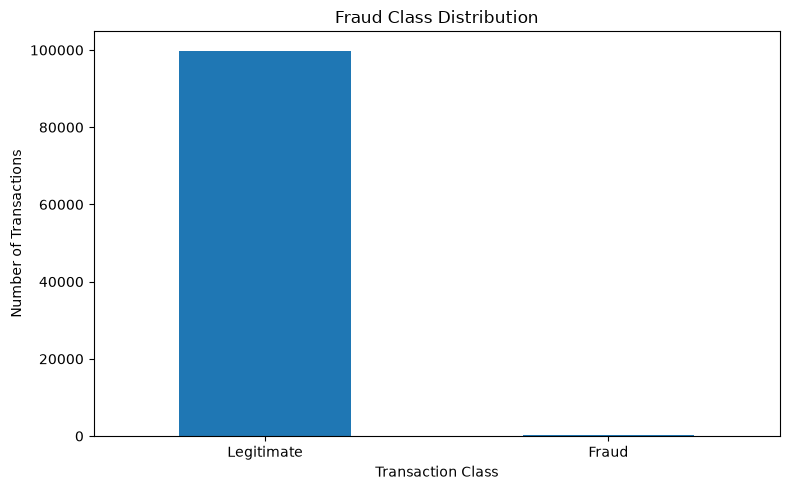

In [10]:
class_plot_data = pd.Series(
    {
        "Legitimate": legitimate_count,
        "Fraud": fraud_count,
    }
)

plt.figure(
    figsize=(8, 5)
)

class_plot_data.plot(
    kind="bar"
)

plt.title(
    "Fraud Class Distribution"
)

plt.xlabel(
    "Transaction Class"
)

plt.ylabel(
    "Number of Transactions"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()


## 9. Transaction-Type Distribution

The dataset contains several financial transaction categories.

The model later receives transaction type as one of its key input features.


In [11]:
transaction_type_counts = (
    df["type"]
    .value_counts()
)

transaction_type_counts


type
CASH_OUT    35194
PAYMENT     33632
CASH_IN     22186
TRANSFER     8355
DEBIT         633
Name: count, dtype: int64

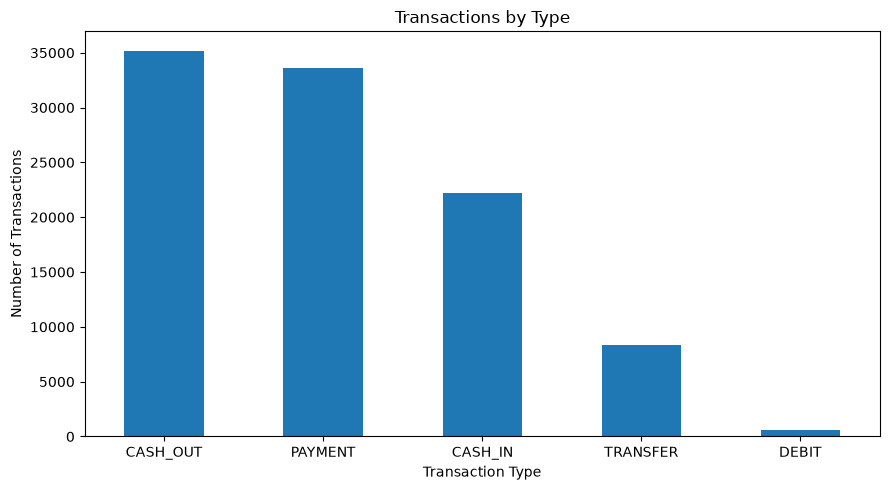

In [12]:
plt.figure(
    figsize=(9, 5)
)

transaction_type_counts.plot(
    kind="bar"
)

plt.title(
    "Transactions by Type"
)

plt.xlabel(
    "Transaction Type"
)

plt.ylabel(
    "Number of Transactions"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()


## 10. Fraud by Transaction Type

This analysis helps determine whether fraud is evenly distributed across
transaction categories or concentrated within particular transaction types.


In [13]:
fraud_by_type = (
    df.groupby("type")[FRAUD_LABEL_COLUMN]
    .agg(
        total_transactions="count",
        fraud_transactions="sum",
        fraud_rate="mean",
    )
    .sort_values(
        "fraud_rate",
        ascending=False,
    )
)

fraud_by_type["fraud_rate_percent"] = (
    fraud_by_type["fraud_rate"]
    * 100
)

fraud_by_type[
    [
        "total_transactions",
        "fraud_transactions",
        "fraud_rate_percent",
    ]
]


,total_transactions,fraud_transactions,fraud_rate_percent
type,,,
DEBIT,633,2,0.315956
PAYMENT,33632,50,0.148668
CASH_IN,22186,32,0.144235
TRANSFER,8355,12,0.143627
CASH_OUT,35194,50,0.142070


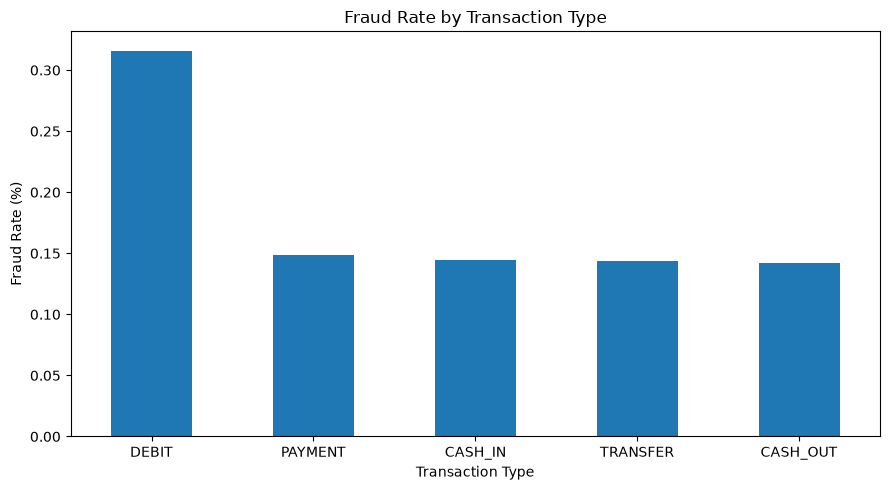

In [14]:
plt.figure(
    figsize=(9, 5)
)

fraud_by_type[
    "fraud_rate_percent"
].plot(
    kind="bar"
)

plt.title(
    "Fraud Rate by Transaction Type"
)

plt.xlabel(
    "Transaction Type"
)

plt.ylabel(
    "Fraud Rate (%)"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()


## 11. Transaction Amount Analysis

Fraud is not determined by amount alone, but transaction value can interact
with transaction type and balance behavior.

Because transaction amounts can be heavily skewed, descriptive statistics
and logarithmic visualizations are both useful.


In [15]:
amount_summary = (
    df.groupby(FRAUD_LABEL_COLUMN)["amount"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max",
        ]
    )
)

amount_summary.index = [
    "Legitimate"
    if index == LEGITIMATE_CLASS
    else "Fraud"
    for index in amount_summary.index
]

amount_summary


,count,mean,median,min,max
Legitimate,99854,180807.617798,82240.550,0.00,3749361.77
Fraud,146,164759.331164,86107.125,0.64,1168771.52


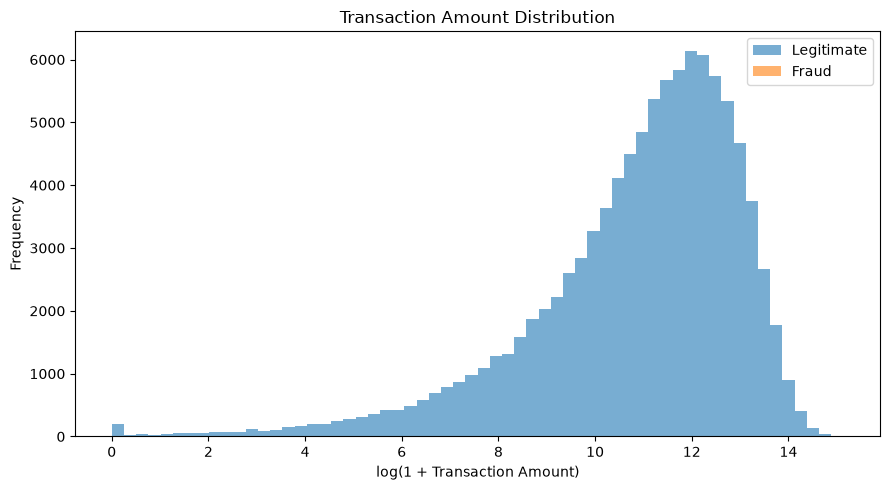

In [16]:
plot_df = df[
    [
        FRAUD_LABEL_COLUMN,
        "amount",
    ]
].copy()

plot_df["log_amount"] = np.log1p(
    plot_df["amount"]
)

legitimate_log_amount = plot_df.loc[
    plot_df[FRAUD_LABEL_COLUMN]
    == LEGITIMATE_CLASS,
    "log_amount",
]

fraud_log_amount = plot_df.loc[
    plot_df[FRAUD_LABEL_COLUMN]
    == FRAUD_CLASS,
    "log_amount",
]

plt.figure(
    figsize=(9, 5)
)

plt.hist(
    legitimate_log_amount,
    bins=60,
    alpha=0.6,
    label="Legitimate",
)

plt.hist(
    fraud_log_amount,
    bins=60,
    alpha=0.6,
    label="Fraud",
)

plt.title(
    "Transaction Amount Distribution"
)

plt.xlabel(
    "log(1 + Transaction Amount)"
)

plt.ylabel(
    "Frequency"
)

plt.legend()

plt.tight_layout()
plt.show()


## 12. Balance-Change Features

The fine-tuned model receives balances before and after each transaction.

For EDA only, we derive additional balance-change variables to make those
relationships easier to understand.

These derived variables are **not automatically added to the model input**.
They are analytical tools for understanding fraud behavior.


In [17]:
analysis_df = df.copy()

analysis_df[
    "sender_balance_change"
] = (
    analysis_df["newbalanceOrig"]
    - analysis_df["oldbalanceOrg"]
)

analysis_df[
    "recipient_balance_change"
] = (
    analysis_df["newbalanceDest"]
    - analysis_df["oldbalanceDest"]
)

analysis_df[
    "sender_balance_depletion"
] = (
    analysis_df["oldbalanceOrg"]
    - analysis_df["newbalanceOrig"]
)

analysis_df[
    "sender_zero_after"
] = (
    analysis_df["newbalanceOrig"]
    == 0
).astype(int)

analysis_df[
    [
        "type",
        "amount",
        "sender_balance_change",
        "recipient_balance_change",
        "sender_balance_depletion",
        "sender_zero_after",
        FRAUD_LABEL_COLUMN,
    ]
].head()


,type,amount,sender_balance_change,recipient_balance_change,sender_balance_depletion,sender_zero_after,isFraud
0,TRANSFER,41971.13,249762.25,147201.41,-249762.25,0,0
1,CASH_IN,29106.70,13432215.27,-1727436.51,-13432215.27,0,0
2,CASH_OUT,46105.50,337240.27,-1891358.07,-337240.27,0,0
3,CASH_OUT,35059.41,196888.94,-674420.13,-196888.94,0,0
4,CASH_OUT,23947.58,3468897.34,-1572285.68,-3468897.34,0,0


## 13. Balance Behavior by Fraud Class


In [18]:
balance_summary = (
    analysis_df.groupby(
        FRAUD_LABEL_COLUMN
    )[
        [
            "sender_balance_change",
            "recipient_balance_change",
            "sender_balance_depletion",
            "sender_zero_after",
        ]
    ]
    .mean()
)

balance_summary.index = [
    "Legitimate"
    if index == LEGITIMATE_CLASS
    else "Fraud"
    for index in balance_summary.index
]

balance_summary


,sender_balance_change,recipient_balance_change,sender_balance_depletion,sender_zero_after
Legitimate,755172.175143,1.524493e+06,-755172.175143,0.001362
Fraud,795664.747808,1.165302e+06,-795664.747808,0.000000


In [19]:
sender_zero_rate = (
    analysis_df.groupby(
        FRAUD_LABEL_COLUMN
    )["sender_zero_after"]
    .mean()
    * 100
)

sender_zero_rate.index = [
    "Legitimate"
    if index == LEGITIMATE_CLASS
    else "Fraud"
    for index in sender_zero_rate.index
]

print(
    "Percentage of transactions where "
    "sender balance becomes zero:"
)

sender_zero_rate


Percentage of transactions where sender balance becomes zero:


Legitimate    0.136199
Fraud         0.000000
Name: sender_zero_after, dtype: float64

## 14. Existing `isFlaggedFraud` Field

The source dataset contains an existing rule-based/simulator flag called
`isFlaggedFraud`.

This field is useful for exploratory comparison but is intentionally
**not included in the model features**.

Using it as a model input would allow the fine-tuned model to learn from an
existing fraud flag instead of learning directly from transaction behavior.


In [20]:
if "isFlaggedFraud" in df.columns:
    flagged_summary = pd.crosstab(
        df["isFlaggedFraud"],
        df[FRAUD_LABEL_COLUMN],
        rownames=["Existing Flag"],
        colnames=["Actual Fraud"],
    )

    display(flagged_summary)

    flagged_count = int(
        df["isFlaggedFraud"].sum()
    )

    actual_fraud_count = int(
        df[FRAUD_LABEL_COLUMN].sum()
    )

    correctly_flagged = int(
        (
            (df["isFlaggedFraud"] == 1)
            & (df[FRAUD_LABEL_COLUMN] == 1)
        ).sum()
    )

    print(
        f"Existing flagged transactions: "
        f"{flagged_count:,}"
    )

    print(
        f"Actual fraud transactions: "
        f"{actual_fraud_count:,}"
    )

    print(
        f"Correct fraud flags: "
        f"{correctly_flagged:,}"
    )
else:
    print(
        "isFlaggedFraud is not available "
        "in this source sample."
    )


Actual Fraud,0,1
Existing Flag,,
0,99854,146


Existing flagged transactions: 0
Actual fraud transactions: 146
Correct fraud flags: 0


## 15. Numerical Correlation Analysis

Correlation does not establish causation, but it helps reveal linear
relationships among transaction values and balances.

The fraud label is included only to observe possible relationships during EDA.


In [21]:
correlation_columns = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    FRAUD_LABEL_COLUMN,
]

correlation_matrix = (
    analysis_df[
        correlation_columns
    ]
    .corr()
)

correlation_matrix


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,0.010165,-0.089249,0.501419,0.462524,-0.002396
oldbalanceOrg,0.010165,1.000000,0.635093,-0.008416,0.012414,-0.000465
newbalanceOrig,-0.089249,0.635093,1.000000,0.012432,-0.041373,0.000100
oldbalanceDest,0.501419,-0.008416,0.012432,1.000000,0.694578,-0.001835
newbalanceDest,0.462524,0.012414,-0.041373,0.694578,1.000000,-0.001829
isFraud,-0.002396,-0.000465,0.000100,-0.001835,-0.001829,1.000000


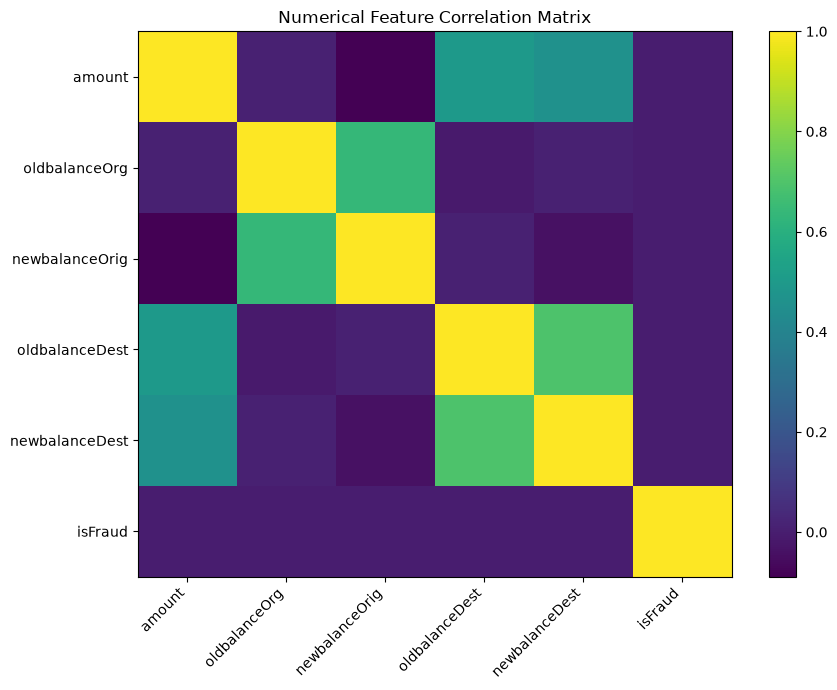

In [22]:
plt.figure(
    figsize=(9, 7)
)

image = plt.imshow(
    correlation_matrix,
    aspect="auto",
)

plt.colorbar(
    image
)

plt.xticks(
    range(
        len(correlation_columns)
    ),
    correlation_columns,
    rotation=45,
    ha="right",
)

plt.yticks(
    range(
        len(correlation_columns)
    ),
    correlation_columns,
)

plt.title(
    "Numerical Feature Correlation Matrix"
)

plt.tight_layout()
plt.show()


## 16. Transaction-Type Validation

The preprocessing pipeline accepts the known transaction categories defined
centrally in the project configuration.


In [23]:
observed_transaction_types = sorted(
    df["type"]
    .dropna()
    .unique()
    .tolist()
)

expected_transaction_types = sorted(
    EXPECTED_TRANSACTION_TYPES
)

unexpected_types = sorted(
    set(observed_transaction_types)
    - set(expected_transaction_types)
)

print(
    "Observed transaction types:",
    observed_transaction_types,
)

print(
    "Expected transaction types:",
    expected_transaction_types,
)

print(
    "Unexpected transaction types:",
    unexpected_types,
)


Observed transaction types: ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
Expected transaction types: ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
Unexpected transaction types: []


## 17. EDA Summary


In [24]:
top_fraud_type = (
    fraud_by_type[
        "fraud_rate_percent"
    ]
    .idxmax()
)

top_fraud_rate = float(
    fraud_by_type.loc[
        top_fraud_type,
        "fraud_rate_percent",
    ]
)

print("=" * 70)
print("FINANCIAL FRAUD DATASET — EDA SUMMARY")
print("=" * 70)

print(
    f"Transactions analyzed: "
    f"{len(df):,}"
)

print(
    f"Fraud transactions: "
    f"{fraud_count:,}"
)

print(
    f"Legitimate transactions: "
    f"{legitimate_count:,}"
)

print(
    f"Observed fraud rate: "
    f"{fraud_rate:.4f}%"
)

print(
    f"Transaction types: "
    f"{', '.join(observed_transaction_types)}"
)

print(
    f"Highest observed fraud-rate type: "
    f"{top_fraud_type} "
    f"({top_fraud_rate:.4f}%)"
)

print(
    f"Missing required columns: "
    f"{len(missing_required)}"
)

print(
    f"Duplicate transactions in EDA sample: "
    f"{duplicate_count:,}"
)

print()
print("Key modelling implications:")
print(
    "1. Fraud is class-imbalanced, so training data "
    "must be balanced carefully."
)

print(
    "2. Transaction type, amount, and balance movement "
    "should be analyzed together rather than independently."
)

print(
    "3. Train and test data must be separated before "
    "balancing to avoid evaluation leakage."
)

print(
    "4. isFlaggedFraud should remain excluded from "
    "model inputs to avoid target-proxy leakage."
)

print(
    "5. The selected model features are available in "
    "the real source dataset and are suitable for the "
    "fine-tuning pipeline."
)

print("=" * 70)


FINANCIAL FRAUD DATASET — EDA SUMMARY
Transactions analyzed: 100,000
Fraud transactions: 146
Legitimate transactions: 99,854
Observed fraud rate: 0.1460%
Transaction types: CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER
Highest observed fraud-rate type: DEBIT (0.3160%)
Missing required columns: 0
Duplicate transactions in EDA sample: 0

Key modelling implications:
1. Fraud is class-imbalanced, so training data must be balanced carefully.
2. Transaction type, amount, and balance movement should be analyzed together rather than independently.
3. Train and test data must be separated before balancing to avoid evaluation leakage.
4. isFlaggedFraud should remain excluded from model inputs to avoid target-proxy leakage.
5. The selected model features are available in the real source dataset and are suitable for the fine-tuning pipeline.


## Conclusion

The exploratory analysis establishes the characteristics of the fraud
dataset before model training.

The source data is naturally imbalanced, which justifies the project's
balanced fine-tuning strategy. Transaction type, amount, sender balances,
recipient balances, and changes between those balances provide the
transaction-level context used by the specialized fraud classifier.

The next stage prepares the data through the project's reusable pipeline:

1. load the source data
2. validate and normalize transaction records
3. create independent train and test partitions
4. balance each partition independently
5. convert the training transactions into Qwen-compatible conversations

That prepared dataset will then be used for QLoRA fine-tuning.
